# 多层感知机

## 环境配置


In [1]:
import os
import sys
import warnings
import logging
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu.env").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="Cannot create tensor with internal format")
import pypto
import torch
from torch import nn
import torch_npu
from d2l import torch as d2l
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import numpy as np

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torch_npu/__init__.py:324: UserWarning: On the interactive interface, the value of TASK_QUEUE_ENABLE is set to 0 by default.                      Do not set it to 1 to prevent some unknown errors
  warnings.warn("On the interactive interface, the value of TASK_QUEUE_ENABLE is set to 0 by default. \


/home/developer/.local/lib/python3.11/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


## 练习4.1.1
计算pReLU激活函数的导数。

**解答：**
由$$pReLU(x)= \begin{cases}x & \text{if } x>=0 \\ \alpha x  & \text{if } x<0 \end{cases}$$ 可得 $$ \frac{d}{d x} pReLU(x)= \begin{cases}1 & \text{if } x>=0 \\ \alpha   & \text{if } x<0 \end{cases}$$

以下使用 `torch` 编程进行验证：


In [ ]:
import torch
from d2l import torch as d2l
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.prelu(x, weight=torch.tensor(0.25))
d2l.plt.figure(figsize=(10, 5))
d2l.plt.subplot(121)
d2l.plot(x.detach(), y.detach(), 'x', 'prelu(x)', figsize=(5, 2.5))
d2l.plt.subplot(122)
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of prelu', figsize=(5, 2.5))
d2l.plt.subplots_adjust(wspace=0.5, hspace=0)

使用 `PyPTO` 编程进行验证:


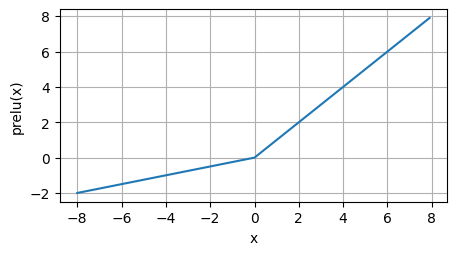

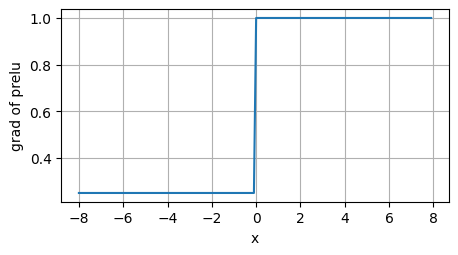

In [2]:
%matplotlib inline
from src.utils import plot
import matplotlib.pyplot as plt
import torch
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.prelu(x,weight=torch.tensor(0.25))
y.backward(torch.ones_like(x), retain_graph=True)
plot(x.detach(), y.detach(), 'x', 'prelu(x)', figsize=(5, 2.5))
plt.show()
plot(x.detach(), x.grad, 'x', 'grad of prelu', figsize=(5, 2.5))
plt.show()

## 练习4.1.2

证明一个仅使用ReLU（或pReLU）的多层感知机构造了一个连续的分段线性函数。

**解答：**

以下证明参考李宏毅老师课程的[讲义](http://speech.ee.ntu.edu.tw/~tlkagk/courses_MLDS18.html) 和[视频](https://www.youtube.com/watch?v=KKT2VkTdFyc&list=RDCMUC2ggjtuuWvxrHHHiaDH1dlQ&index=2)。

首先介绍L-Lipschitz连续函数的性质。一个目标函数 $f^*$ 如果满足L-Lipschitz条件，意味着它在任意两点上的变化幅度受限于这两点之间的距离乘以 $L$。具体而言，对于定义域中的任意两点 $x_1$ 和 $x_2$，满足：
$$\left\|f^*\left(x_1\right)-f^*\left(x_2\right)\right\| \leq L\left\|x_1-x_2\right\|$$
直观理解：$L$ 越大，函数可以变化得越剧烈；$L$ 越小，函数则越平缓。

我们现在要完成的目标是：使用ReLU多层感知机来近似一个连续的L-Lipschitz函数 $f^*(x)$。假设定义域为区间 $[0, 1]$，并设定一个可接受的误差上限 $\epsilon$。当构造的近似函数 $f(x)$ 满足以下条件时，就认为近似成功：
$$\max _{0 \leq x \leq 1}\left|f(x)-f^*(x)\right| \leq \varepsilon \Leftrightarrow \int_0^1\left|f(x)-f^*(x)\right|^2 d x \leq \varepsilon$$

下面说明ReLU为什么有能力做到。先看一个简单情况：一段折线可以用两个ReLU神经元完美拟合。将这个思路推广到一般情况，任意连续函数都可以被切成许多小段折线，而每一小段都可以用两个ReLU神经元来近似。

因此核心问题是：需要把定义域切成多细的小段，才能让每一段上的近似误差都不超过 $\epsilon$？答案是每段长度 $d$ 取 $\frac{\epsilon}{L}$ 即可。以下是证明。

对于长度为 $d$ 的任意一个小子区间，考虑在该区间上 $f(x)$ 和 $f^*(x)$ 误差最大的情况。设 $x_1$ 和 $x_2$ 分别是 $f^*$ 在该子区间上取得最大值和最小值的两点，则有：
$$\max_{\text{长度为d的小段范围}}\left|f(x)-f^*(x)\right| \leq\left|f^*(x_1)-f^*(x_2)\right|\leq L \left|x_1-x_2\right| \leq  Ld$$
因此只要 $Ld\leq \epsilon$ 就能保证每个小段上的近似误差不超过 $\epsilon$。由此推出每段长度取 $d = \frac{\epsilon}{L}$。

知道了每段长度 $d$，即可计算总共需要的小段数：$\frac{1}{d} = \frac{L}{\epsilon}$。因为每段用两个ReLU神经元，最终需要 $\frac{2L}{\epsilon}$ 个ReLU神经元。

## 练习4.1.3
证明$\operatorname{tanh}(x) + 1 = 2 \operatorname{sigmoid}(2x)$。

**解答：** 
已知：$$\operatorname{tanh}(x)=\frac{1 - \exp(-2x)}{1 + \exp(-2x)}$$
故左式：$$\operatorname{tanh}(x) + 1 =\frac{1 - \exp(-2x)}{1 + \exp(-2x)}+1= \frac{2}{1 + \exp(-2x)}$$   
同时有$$\operatorname{sigmoid}(2x)= \frac{1}{1 + \exp(-2x)}$$ 
故易证 左式=右式

以下使用 `torch` 编程进行验证：


In [ ]:
x = torch.arange(-8.0, 8.0, 0.1)
y1 = torch.tanh(x) + 1.0
y2 = 2.0 * torch.sigmoid(2.0 * x)
d2l.plot(x.detach().numpy(), [y1.detach(), y2.detach()],
         legend=['tanh(x)+1', '2sigmoid(2x)'], figsize=(4.5, 2.5))
d2l.plt.xlabel("X")
d2l.plt.ylabel("Y")

使用 `PyPTO` 编程进行验证:


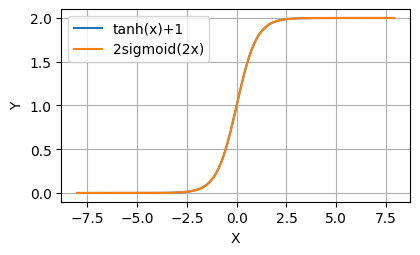

In [2]:
from src.utils import plot
import matplotlib.pyplot as plt
x = torch.arange(-8.0, 8.0, 0.1)
y1 = torch.tanh(x)+1.0
y2 = 2.0*torch.sigmoid(2.0*x)
plot(x.detach().numpy(), [y1.detach(), y2.detach()],
         'X', 'Y', legend=['tanh(x)+1', '2sigmoid(2x)'], figsize=(4.5, 2.5))


## 练习4.1.4

假设我们有一个非线性单元，将它直接应用于一个小批量的数据。这会导致什么样的问题？

**解答：**
将非线性单元直接应用于一个小批量的数据可能会导致以下问题：

1. **信息丢失**：非线性单元通常引入非线性变换，将输入数据映射到新的表示空间。当应用于小批量的数据时，可能会存在数据样本之间的相关性和多样性不足的问题。这可能导致一部分样本的信息丢失或被模糊化，因为小批量数据可能无法充分捕捉到全局数据分布的特征。

2. **噪声放大**：小批量数据通常包含相对较少的样本，其中可能存在噪声或异常值。当非线性单元应用于这些数据时，噪声和异常值可能被放大，导致输出结果出现不稳定或错误的情况。

3. **参数更新不准确**：在训练神经网络时，通过反向传播算法进行参数更新。当应用非线性单元于小批量数据时，由于数据的有限性，可能导致梯度估计的不准确性。这可能影响参数的更新过程，使得网络收敛速度变慢或无法达到最佳状态。

4. **过拟合风险增加**：小批量数据的样本量较少，这可能增加过拟合的风险。由于小批量数据可能无法充分代表整体数据分布，模型可能更容易过度拟合训练集，导致泛化性能下降。

为了缓解这些问题，可以考虑以下方法：

- 增加小批量数据的样本量，以更好地代表整体数据分布。
- 使用正则化技术（如L1或L2正则化）来控制模型的复杂度，减少过拟合风险。
- 使用数据增强技术来扩充小批量数据的多样性，增加训练样本的数量和质量。
- 采用批归一化等技术来规范化输入数据，以减小噪声的影响。
- 如果可行，考虑使用更大的批量数据来提高模型性能和稳定性。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
